# 4. 多项式回归实现与应用


## 4.1. 介绍

前面的实验中，相信你已经对线性回归有了充分的了解。掌握一元和多元线性回归之后，我们就能针对一些有线性分布趋势的数据进行回归预测。但是，生活中还常常会遇到一些分布不那么「线性」的数据，例如像股市的波动、交通流量等。那么对于这类非线性分布的数据，就需要通过本次实验介绍的方法来处理。


## 4.2. 知识点

* 多项式回归介绍
* 多项式回归基础
* 多项式回归预测


## 4.3. 多项式回归介绍

在线性回归中，我们通过建立自变量\\(x\\) 的一次方程来拟合数据。而非线性回归中，则需要建立因变量和自变量之间的非线性关系。从直观上讲，也就是拟合的直线变成了「曲线」。

对于非线性回归问题而言，最简单也是最常见的方法就是本次实验要讲解的「多项式回归」。多项式是中学时期就会接触到的概念，这里引用维基百科的定义如下：

多项式（Polynomial）是代数学中的基础概念，是由称为未知数的变量和称为系数的常量通过有限次加法、加减法、乘法以及自然数幂次的乘方运算得到的代数表达式。多项式是整式的一种。未知数只有一个的多项式称为一元多项式；例如\\(x^2-3x+4\\) 就是一个一元多项式。未知数不止一个的多项式称为多元多项式，例如\\(x^3-2xyz^2+2yz+1\\) 就是一个三元多项式。


## 4.4. 多项式回归基础

首先，我们通过一组示例数据来认识多项式回归


In [1]:
# 加载示例数据
x = [4, 8, 12, 25, 32, 43, 58, 63, 69, 79]
y = [20, 33, 50, 56, 42, 31, 33, 46, 65, 75]


示例数据一共有 10 组，分别对应着横坐标和纵坐标。接下来，通过 Matplotlib 绘制数据，查看其变化趋势。


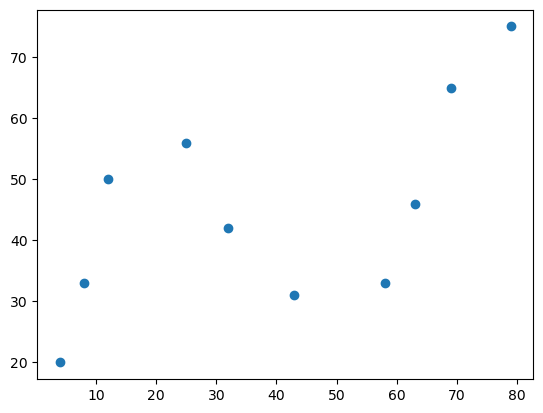

In [2]:
from matplotlib import pyplot as plt

%matplotlib inline

plt.scatter(x, y)


## 4.5. 实现 2 次多项式拟合

接下来，通过多项式来拟合上面的散点数据。首先，一个标准的一元高阶多项式函数如下所示：

\\[ y(x, w) = w_0 + w_1x + w_2x^2 +...+w_mx^m = \\sum\\limits_{j=0}^{m}w_jx^j \\tag{1} \\]

其中，\\(m\\) 表示多项式的阶数，\\(x^j\\) 表示\\(x\\) 的\\(j\\) 次幂，\\(w\\) 则代表该多项式的系数。

当我们使用上面的多项式去拟合散点时，需要确定两个要素，分别是：多项式系数\\(w\\) 以及多项式阶数\\(m\\)，这也是多项式的两个基本要素。

如果通过手动指定多项式阶数\\(m\\) 的大小，那么就只需要确定多项式系数\\(w\\) 的值是多少。例如，这里首先指定\\(m=2\\)，多项式就变成了：

\\[ y(x, w) = w_0 + w_1x + w_2x^2= \\sum\\limits_{j=0}^{2}w_jx^j \\tag{2} \\]

当我们确定\\(w\\) 的值的大小时，就回到了前面线性回归中学习到的内容。

首先，我们构造两个函数，分别是用于拟合的多项式函数，以及误差函数。


In [3]:
def func(p, x):
    # 根据公式，定义 2 次多项式函数
    w0, w1, w2 = p
    f = w0 + w1 * x + w2 * x * x
    return f


def err_func(p, x, y):
    # 定义误差函数
    ret = func(p, x) - y
    return ret


接下来，我们使用 scipy.optimize.leastsq 方法来进行最小二乘拟合。


In [4]:
import numpy as np
from scipy.optimize import leastsq

# 定义初始参数
p_init = np.random.randn(3)

# 最小二乘拟合
parameters = leastsq(err_func, p_init, args=(np.array(x), np.array(y)))
print("拟合参数:", parameters[0])


拟合参数: [ 3.76893106e+01 -2.60474058e-01  8.00077975e-03]


接下来，我们绘制拟合结果。


Text(0, 0.5, 'y')

/Users/kevinlou/miniforge3/envs/dsml-py311/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from current font.
  func(*args, **kwargs)
/Users/kevinlou/miniforge3/envs/dsml-py311/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from current font.
  func(*args, **kwargs)
/Users/kevinlou/miniforge3/envs/dsml-py311/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 39033 (\N{CJK UNIFIED IDEOGRAPH-9879}) missing from current font.
  func(*args, **kwargs)
/Users/kevinlou/miniforge3/envs/dsml-py311/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 24335 (\N{CJK UNIFIED IDEOGRAPH-5F0F}) missing from current font.
  func(*args, **kwargs)
/Users/kevinlou/miniforge3/envs/dsml-py311/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 22238 (\N{CJK UNIFIED IDEOGRAPH-56DE}) missing fro

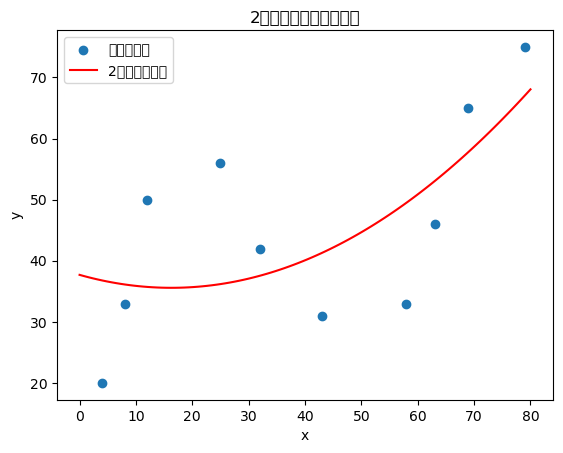

In [5]:
# 绘制原始数据点
plt.scatter(x, y, label="原始数据点")

# 绘制拟合曲线
x_plot = np.linspace(0, 80, 100)
y_plot = func(parameters[0], x_plot)
plt.plot(x_plot, y_plot, 'r-', label="2次多项式拟合")

plt.legend()
plt.title("2次多项式回归拟合结果")
plt.xlabel("x")
plt.ylabel("y")


## 4.6. 实现 N 次多项式拟合

接下来，我们实现一个通用的 N 次多项式拟合函数。


In [6]:
def poly_func(p, x, degree):
    """
    通用多项式函数
    p: 多项式系数
    x: 自变量
    degree: 多项式次数
    """
    f = np.zeros_like(x)
    for i in range(degree + 1):
        f += p[i] * (x ** i)
    return f


def poly_err_func(p, x, y, degree):
    """
    多项式误差函数
    """
    ret = poly_func(p, x, degree) - y
    return ret


现在，我们使用 3 次多项式来拟合数据。


In [7]:
# 3次多项式拟合
degree = 3
p_init = np.random.randn(degree + 1)
parameters_3 = leastsq(poly_err_func, p_init, args=(np.array(x), np.array(y), degree))
print("3次多项式拟合参数:", parameters_3[0])


UFuncTypeError: Cannot cast ufunc 'add' output from dtype('float64') to dtype('int64') with casting rule 'same_kind'

In [ ]:
# 绘制3次多项式拟合结果
plt.scatter(x, y, label="原始数据点")

x_plot = np.linspace(0, 80, 100)
y_plot_3 = poly_func(parameters_3[0], x_plot, degree)
plt.plot(x_plot, y_plot_3, 'g-', label="3次多项式拟合")

plt.legend()
plt.title("3次多项式回归拟合结果")
plt.xlabel("x")
plt.ylabel("y")


## 4.7. 使用 scikit-learn 进行多项式拟合

接下来，我们使用 scikit-learn 中的 PolynomialFeatures 和 LinearRegression 来实现多项式回归。


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# 使用 scikit-learn 进行2次多项式拟合
model_2 = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
model_2.fit(np.array(x).reshape(-1, 1), np.array(y))

# 预测
x_plot_sklearn = np.linspace(0, 80, 100).reshape(-1, 1)
y_pred_2 = model_2.predict(x_plot_sklearn)

# 绘制结果
plt.scatter(x, y, label="原始数据点")
plt.plot(x_plot_sklearn, y_pred_2, 'r-', label="sklearn 2次多项式拟合")
plt.legend()
plt.title("使用 scikit-learn 的2次多项式回归")
plt.xlabel("x")
plt.ylabel("y")


## 4.8. 多项式回归预测

现在，我们使用训练好的模型进行预测。


In [ ]:
# 预测新数据点
new_x = [85, 90, 95]
new_x_array = np.array(new_x).reshape(-1, 1)
predictions = model_2.predict(new_x_array)

print("预测结果:")
for i, (x_val, y_pred) in enumerate(zip(new_x, predictions)):
    print(f"x = {x_val}, 预测 y = {y_pred:.2f}")


## 4.9. 线性回归与 2 次多项式回归对比

接下来，我们对比线性回归和2次多项式回归的效果。


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# 线性回归
linear_model = LinearRegression()
linear_model.fit(np.array(x).reshape(-1, 1), np.array(y))
y_pred_linear = linear_model.predict(np.array(x).reshape(-1, 1))

# 2次多项式回归
y_pred_poly = model_2.predict(np.array(x).reshape(-1, 1))

# 计算评估指标
mse_linear = mean_squared_error(y, y_pred_linear)
mse_poly = mean_squared_error(y, y_pred_poly)
r2_linear = r2_score(y, y_pred_linear)
r2_poly = r2_score(y, y_pred_poly)

print("线性回归 MSE:", mse_linear)
print("2次多项式回归 MSE:", mse_poly)
print("线性回归 R²:", r2_linear)
print("2次多项式回归 R²:", r2_poly)


In [ ]:
# 可视化对比
plt.scatter(x, y, label="原始数据点", alpha=0.7)

# 线性回归拟合线
x_plot = np.linspace(0, 80, 100).reshape(-1, 1)
y_linear_plot = linear_model.predict(x_plot)
plt.plot(x_plot, y_linear_plot, 'b-', label=f"线性回归 (R²={r2_linear:.3f})")

# 2次多项式回归拟合线
y_poly_plot = model_2.predict(x_plot)
plt.plot(x_plot, y_poly_plot, 'r-', label=f"2次多项式回归 (R²={r2_poly:.3f})")

plt.legend()
plt.title("线性回归 vs 2次多项式回归对比")
plt.xlabel("x")
plt.ylabel("y")


## 4.10. 更高次多项式回归预测

现在，我们尝试使用更高次的多项式进行拟合。


In [ ]:
# 尝试不同次数的多项式
degrees = [1, 2, 3, 4, 5]
colors = ['blue', 'red', 'green', 'orange', 'purple']

plt.figure(figsize=(12, 8))
plt.scatter(x, y, label="原始数据点", s=100, alpha=0.7)

x_plot = np.linspace(0, 80, 100).reshape(-1, 1)

for i, degree in enumerate(degrees):
    model = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False), LinearRegression())
    model.fit(np.array(x).reshape(-1, 1), np.array(y))
    y_pred = model.predict(x_plot)
    
    # 计算R²分数
    y_pred_train = model.predict(np.array(x).reshape(-1, 1))
    r2 = r2_score(y, y_pred_train)
    
    plt.plot(x_plot, y_pred, color=colors[i], label=f"{degree}次多项式 (R²={r2:.3f})")

plt.legend()
plt.title("不同次数多项式回归对比")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)


## 4.11. 多项式回归预测次数选择

接下来，我们通过交叉验证来选择最优的多项式次数。


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer

# 使用交叉验证选择最优次数
degrees = range(1, 8)
cv_scores = []

for degree in degrees:
    model = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False), LinearRegression())
    scores = cross_val_score(model, np.array(x).reshape(-1, 1), np.array(y), cv=5, scoring='neg_mean_squared_error')
    cv_scores.append(-scores.mean())

# 绘制交叉验证结果
plt.figure(figsize=(10, 6))
plt.plot(degrees, cv_scores, 'bo-', linewidth=2, markersize=8)
plt.xlabel('多项式次数')
plt.ylabel('交叉验证MSE')
plt.title('不同次数多项式的交叉验证MSE')
plt.grid(True, alpha=0.3)

# 找到最优次数
best_degree = degrees[np.argmin(cv_scores)]
print(f"最优多项式次数: {best_degree}")
print(f"对应的交叉验证MSE: {min(cv_scores):.4f}")


## 4.12. 总结

通过本次实验，我们学习了多项式回归的基本概念和实现方法：

1. **多项式回归基础**：多项式回归是线性回归的扩展，通过引入高次项来拟合非线性数据。

2. **实现方法**：
   - 使用 scipy.optimize.leastsq 进行手动拟合
   - 使用 scikit-learn 的 PolynomialFeatures 和 LinearRegression

3. **模型评估**：通过 MSE、R² 等指标评估模型性能。

4. **次数选择**：通过交叉验证选择最优的多项式次数，避免过拟合。

5. **应用场景**：多项式回归适用于具有非线性关系的数据，如股市波动、交通流量等。

多项式回归是机器学习中的重要方法，它为处理非线性数据提供了简单而有效的解决方案。在实际应用中，需要根据数据特点选择合适的多项式次数，并通过交叉验证等方法进行模型选择。


# 4. 多项式回归实现与应用

In [ ]:
# 加载示例数据
x = [4, 8, 12, 25, 32, 43, 58, 63, 69, 79]
y = [20, 33, 50, 56, 42, 31, 33, 46, 65, 75]

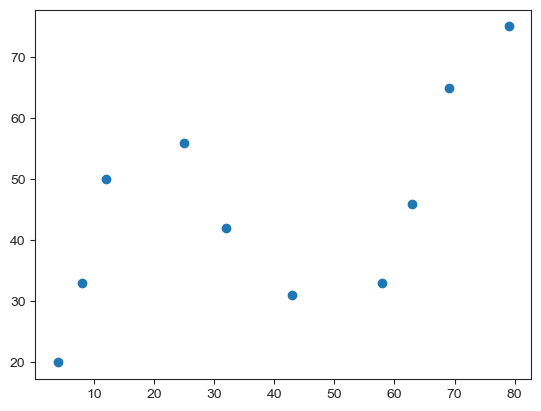

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

# custom_params = {"figure.figsize": (6, 4),
#                  "font.sans-serif":"Arial Unicode MS",
#                  'axes.unicode_minus': False}
# sns.set_theme(style="ticks", font_scale=0.7, rc=custom_params)
sns.set_style("ticks")

plt.scatter(x, y)

In [ ]:
import pandas as pd

url = 'https://raw.githubusercontent.com/GeostatsGuy/GeoDataSets/master/1D_Porosity.csv' 
df = pd.read_csv(url)
df.head()

,Depth,Nporosity
0,0.25,-1.37
1,0.50,-2.08
2,0.75,-1.67
3,1.00,-1.16
4,1.25,-0.24


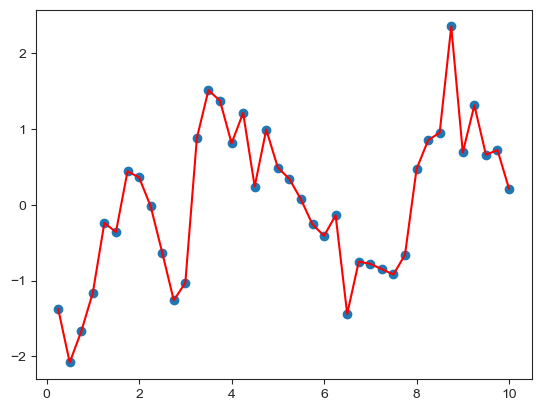

In [ ]:
# 定义 x, y 的取值
x = df["Depth"]
y = df["Nporosity"]
# 绘图
plt.plot(x, y, "r")
plt.scatter(x, y)

In [ ]:
# 首先划分 dateframe 为训练集和测试集
train_df = df[: int(len(df) * 0.7)]
test_df = df[int(len(df) * 0.7) :]

# 定义训练和测试使用的自变量和因变量
X_train = train_df["Depth"].values
y_train = train_df["Nporosity"].values

X_test = test_df["Depth"].values
y_test = test_df["Nporosity"].values

In [ ]:
from sklearn.linear_model import LinearRegression

# 建立线性回归模型
model = LinearRegression()
model.fit(X_train.reshape(len(X_train), 1), y_train.reshape(len(y_train), 1))
results = model.predict(X_test.reshape(len(X_test), 1))
results  # 线性回归模型在测试集上的预测结果

array([[0.26222222],
       [0.29235085],
       [0.32247947],
       [0.3526081 ],
       [0.38273673],
       [0.41286535],
       [0.44299398],
       [0.47312261],
       [0.50325123],
       [0.53337986],
       [0.56350848],
       [0.59363711]])

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

print("线性回归平均绝对误差: ", mean_absolute_error(y_test, results.flatten()))
print("线性回归均方误差: ", mean_squared_error(y_test, results.flatten()))

线性回归平均绝对误差:  0.668851943076081
线性回归均方误差:  0.7262482710699257


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# 2 次多项式回归特征矩阵
poly_features_2 = PolynomialFeatures(degree=2, include_bias=False)
poly_X_train_2 = poly_features_2.fit_transform(X_train.reshape(len(X_train), 1))
poly_X_test_2 = poly_features_2.fit_transform(X_test.reshape(len(X_test), 1))

# 2 次多项式回归模型训练与预测
model = LinearRegression()
model.fit(poly_X_train_2, y_train.reshape(len(X_train), 1))  # 训练模型

results_2 = model.predict(poly_X_test_2)  # 预测结果

results_2.flatten()  # 打印扁平化后的预测结果

array([-1.41682234, -1.73408225, -2.07450139, -2.43807977, -2.82481738,
       -3.23471422, -3.6677703 , -4.12398562, -4.60336017, -5.10589396,
       -5.63158699, -6.18043924])

In [ ]:
print("2 次多项式回归平均绝对误差: ", mean_absolute_error(y_test, results_2.flatten()))
print("2 次多项式均方误差: ", mean_squared_error(y_test, results_2.flatten()))

2 次多项式回归平均绝对误差:  4.068004469987231
2 次多项式均方误差:  20.936635430648945


In [ ]:
from sklearn.pipeline import make_pipeline

X_train = X_train.reshape(len(X_train), 1)
X_test = X_test.reshape(len(X_test), 1)
y_train = y_train.reshape(len(y_train), 1)

for m in [3, 4, 5]:
    model = make_pipeline(PolynomialFeatures(m, include_bias=False), LinearRegression())
    model.fit(X_train, y_train)
    pre_y = model.predict(X_test)
    print("{} 次多项式回归平均绝对误差: ".format(m), mean_absolute_error(y_test, pre_y.flatten()))
    print("{} 次多项式均方误差: ".format(m), mean_squared_error(y_test, pre_y.flatten()))
    print("---")

3 次多项式回归平均绝对误差:  5.129257302352646
3 次多项式均方误差:  33.531553828627324
---
4 次多项式回归平均绝对误差:  2.3082420473069822
4 次多项式均方误差:  6.639506434094571
---
5 次多项式回归平均绝对误差:  21.562146337862032
5 次多项式均方误差:  951.7450539295969
---


## 4.11. 多项式回归预测次数选择

MSE 计算结果:  [0.7262482710699257, 20.936635430648945, 33.531553828627324, 6.639506434094571, 951.7450539295969, 5951.756389947962, 164169.2648002583, 1124239.210057049, 8501435.234869642, 125938566.68847854]


Text(0, 0.5, 'MSE')

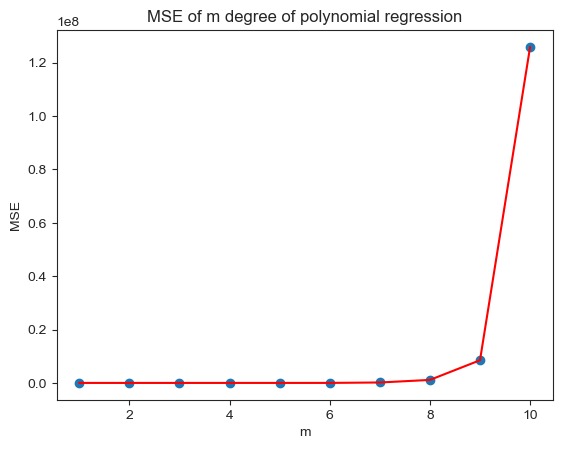

In [ ]:
# 计算 m 次多项式回归预测结果的 MSE 评价指标并绘图
mse = []  # 用于存储各最高次多项式 MSE 值
m = 1  # 初始 m 值
m_max = 10  # 设定最高次数
while m <= m_max:
    model = make_pipeline(PolynomialFeatures(m, include_bias=False), LinearRegression())
    model.fit(X_train, y_train)  # 训练模型
    pre_y = model.predict(X_test)  # 测试模型
    mse.append(mean_squared_error(y_test, pre_y.flatten()))  # 计算 MSE
    m = m + 1

print("MSE 计算结果: ", mse)
# 绘图
plt.plot([i for i in range(1, m_max + 1)], mse, "r")
plt.scatter([i for i in range(1, m_max + 1)], mse)

# 绘制图名称等
plt.title("MSE of m degree of polynomial regression")
plt.xlabel("m")
plt.ylabel("MSE")